# Mini Pilot — n=10 Cost Target + Episode-scale Dual

前回のonline `n=10` Pilotから、**dual更新時間尺度だけ**を変更します。Cost Critic・Actor・Reward Criticはtransition/gradient単位で学習しますが、λはepisode終了時に現在の初期状態分布 `s₀ ~ μ` を再評価して1回だけ更新します。

Stooke et al. (ICML 2020) が指摘する通常Lagrangianの積分制御的なovershoot問題を背景としますが、このPilotはPID Lagrangianの再現ではありません。まず過剰な積分回数をepisodic CMDPの時間尺度へ揃える一因子診断です。

固定条件：`n=10`, `d_cost=6`, dual LR `0.001`, 同一30 scenario、同一seed、HOCBF ON。

In [1]:
from pathlib import Path
from copy import deepcopy
import json, platform
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, HTML

ROOT = Path.cwd().resolve()
if not (ROOT/'uav_safe_marl').is_dir(): ROOT = ROOT.parent
SOURCE_RUN = ROOT/'runs'/'mini_pilot_episodic_dcost6_mps'
GRADIENT_N10_RUN = ROOT/'runs'/'online_cal_n10_dcost6_mps'
RUN_DIR = ROOT/'runs'/'online_cal_n10_episode_dual_dcost6_mps'
D_COST = 6.0
COST_N_STEP = 10
DUAL_LR = 0.001
DUAL_UPDATE_INTERVAL_EPISODES = 1
RESUME_IF_AVAILABLE = True
for path in (SOURCE_RUN/'resolved_config.json', SOURCE_RUN/'training_bank.json', SOURCE_RUN/'calibration_bank.json'):
    if not path.exists(): raise FileNotFoundError(path)
print({'run':str(RUN_DIR),'n_step':COST_N_STEP,'d_cost':D_COST,'dual_lr_per_episode':DUAL_LR})

{'run': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/online_cal_n10_episode_dual_dcost6_mps', 'n_step': 10, 'd_cost': 6.0, 'dual_lr_per_episode': 0.001}


In [2]:
print({'platform':platform.platform(),'python':platform.python_version(),'torch':torch.__version__,'mps_available':torch.backends.mps.is_available()})
if not torch.backends.mps.is_available(): raise RuntimeError('VS Codeでプロジェクトの.venvカーネルを選択してください。')
probe=torch.ones((128,128),device='mps'); print({'device':str(probe.device),'probe':float((probe@probe).sum().cpu())}); del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'python': '3.13.3', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 2097152.0}


## 1. 同一scenario・同一学習条件の構成

前回と同じbankを直接読み込みます。offline Cost Critic checkpointは初期値に使用しません。

In [3]:
from uav_safe_marl import build_env, load_config
from uav_safe_marl.evaluation import load_scenario_bank
from uav_safe_marl.runners.trainer import SafeRLTrainer

training_bank=load_scenario_bank(SOURCE_RUN/'training_bank.json')
calibration_bank=load_scenario_bank(SOURCE_RUN/'calibration_bank.json')
overrides=json.loads((SOURCE_RUN/'resolved_config.json').read_text(encoding='utf-8'))
overrides['device']='mps'
overrides['learning'].update({'d_cost':D_COST,'cost_target_n_step':COST_N_STEP,'cal_lambda_lr':DUAL_LR})
overrides['training'].update({'total_environment_steps_budget':None,'checkpoint_every_episodes':1,'dual_update_mode':'episode','dual_update_interval_episodes':DUAL_UPDATE_INTERVAL_EPISODES})
overrides['monitoring'].update({'enabled':True,'progress_bar':True,'tensorboard':True,'auto_launch_tensorboard':True,'open_browser':True})
config=load_config(ROOT/'configs'/'full.yaml',overrides=overrides)
assert config.learning.cost_target_n_step==10 and config.learning.d_cost==6.0
assert config.training.dual_update_mode=='episode' and config.training.dual_update_interval_episodes==1
RUN_DIR.mkdir(parents=True,exist_ok=True)
(RUN_DIR/'resolved_config.json').write_text(json.dumps(config.to_dict(),indent=2),encoding='utf-8')
print({'episodes':len(training_bank),'N_order':[x['actual_agent_count'] for x in training_bank[:12]],'learning_starts':config.training.learning_starts,'dual_learning_starts':config.training.dual_learning_starts,'dual_mode':config.training.dual_update_mode})

{'episodes': 30, 'N_order': [2, 4, 8, 2, 4, 8, 2, 4, 8, 2, 4, 8], 'learning_starts': 2000, 'dual_learning_starts': 2000, 'dual_mode': 'episode'}


## 2. 学習

Notebook内にtqdmを表示し、TensorBoardを自動起動します。中断後はepisode境界checkpointから再開できます。

In [4]:
latest=RUN_DIR/'checkpoints'/'latest.pt'; final=RUN_DIR/'checkpoints'/'final.pt'
trainer=SafeRLTrainer(config,build_env(config),RUN_DIR/'training')
if RESUME_IF_AVAILABLE and latest.exists():
    trainer.load_checkpoint(latest,resume_training=True)
    trainer.logger.truncate_after_episode(trainer.completed_episodes)
    print(f'{trainer.completed_episodes} episode地点から再開します。')
remaining=len(training_bank)-trainer.completed_episodes
display(HTML(f"<b>TensorBoard:</b> 学習開始後に自動起動します。ログ: <code>{RUN_DIR/'training'/'tensorboard'}</code>"))
try:
    history=trainer.train(episodes=remaining,scenarios=training_bank,live_display=True,checkpoint_path=latest) if remaining>0 else []
    trainer.save_checkpoint(final)
finally:
    trainer.env.close()
print({'completed_episodes':trainer.completed_episodes,'environment_steps':trainer.total_environment_steps,'gradient_updates':trainer.total_gradient_updates,'dual_updates':trainer.backend.dual_update_count,'final_lambda':trainer.backend.dual.value,'checkpoint':str(final)})

Training:   0%|          | 0/30 [00:00<?, ?episode/s]

TensorBoard: http://127.0.0.1:50839/
{'completed_episodes': 30, 'environment_steps': 11986, 'gradient_updates': 9987, 'dual_updates': 24, 'final_lambda': 0.6344079933166504, 'checkpoint': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/online_cal_n10_episode_dual_dcost6_mps/checkpoints/final.pt'}


## 3. 正式stochastic Calibration

In [5]:
from uav_safe_marl.evaluation import calibrate_cost_critic, evaluate_mean_policy_cost_diagnostic
eval_overrides=deepcopy(config.to_dict())
eval_overrides['monitoring'].update({'enabled':False,'progress_bar':False,'tensorboard':False,'auto_launch_tensorboard':False,'open_browser':False})
eval_config=load_config(ROOT/'configs'/'full.yaml',overrides=eval_overrides)
evaluator=SafeRLTrainer(eval_config,build_env(eval_config),RUN_DIR/'frozen_evaluation')
evaluator.load_checkpoint(final,resume_training=False)
try:
    calibration=calibrate_cost_critic(evaluator,calibration_bank,repeats=3,output_dir=RUN_DIR/'cost_calibration')
    mean_diagnostic=evaluate_mean_policy_cost_diagnostic(evaluator,calibration_bank,repeats=1,output_dir=RUN_DIR/'mean_policy_diagnostic')
finally:
    evaluator.env.close()
print(json.dumps({'formal_stochastic_calibration':calibration['overall'],'by_N':calibration['by_agent_count'],'mean_policy':{k:v for k,v in mean_diagnostic.items() if k!='rows'}},ensure_ascii=False,indent=2))

{
  "formal_stochastic_calibration": {
    "count": 27,
    "mc_return_mean": 14.29442084439922,
    "mc_return_median": 8.035190662466041,
    "mean_estimate_bias": 3.497399611081286,
    "ucb_estimate_bias": 8.957091789030414,
    "mean_estimate_mae": 19.02177959282842,
    "mean_estimate_rmse": 25.02077196528937,
    "ucb_estimate_mae": 24.226304171844436,
    "correlation": -0.3683600941682032,
    "empirical_ucb_coverage": 0.7777777777777778,
    "mc_return_p75": 21.780282735790934,
    "mc_return_p90": 37.56298900647974,
    "mc_return_p95": 59.81528148492485,
    "mc_return_max": 72.45416800185893
  },
  "by_N": {
    "2": {
      "count": 9,
      "mc_return_mean": 0.015923801662950668,
      "mc_return_median": 0.0,
      "mean_estimate_bias": 20.481883860029352,
      "ucb_estimate_bias": 24.77532483776169,
      "mean_estimate_mae": 20.481883860029352,
      "mean_estimate_rmse": 23.525211710046765,
      "ucb_estimate_mae": 24.77532483776169,
      "correlation": -0.7398109

## 4. 旧n=1・gradient-dual n=10との比較

episode単位の学習曲線と、λ増加量が更新回数の変更どおり抑制されたかを保存します。

{'design': {'cost_target_n_step': 10,
  'dual_update_mode': 'episode',
  'dual_lr_per_episode': 0.001,
  'd_cost': 6.0,
  'episodes': 30},
 'training': {'environment_steps': 11986,
  'gradient_updates': 9987,
  'dual_updates': 24,
  'final_lambda': 0.6344079933166504,
  'max_lambda': 0.6344079933166504,
  'mean_discounted_cost': 23.923985152928864,
  'last10_discounted_cost': 13.169360475904545,
  'mean_actor_loss': 576.1569124857584,
  'max_actor_loss': 1829.0213623046875,
  'success_rate': 1.0,
  'separation_violation_rate': 0.0},
 'calibration': {'mc_mean': 14.29442084439922,
  'ucb_mean': 23.251512633429634,
  'ucb_mae': 24.226304171844436,
  'correlation': -0.3683600941682032,
  'coverage': 0.7777777777777778,
  'fraction_mc_above_d_cost': 0.5185185185185185,
  'fraction_ucb_above_d_cost': 0.8888888888888888}}

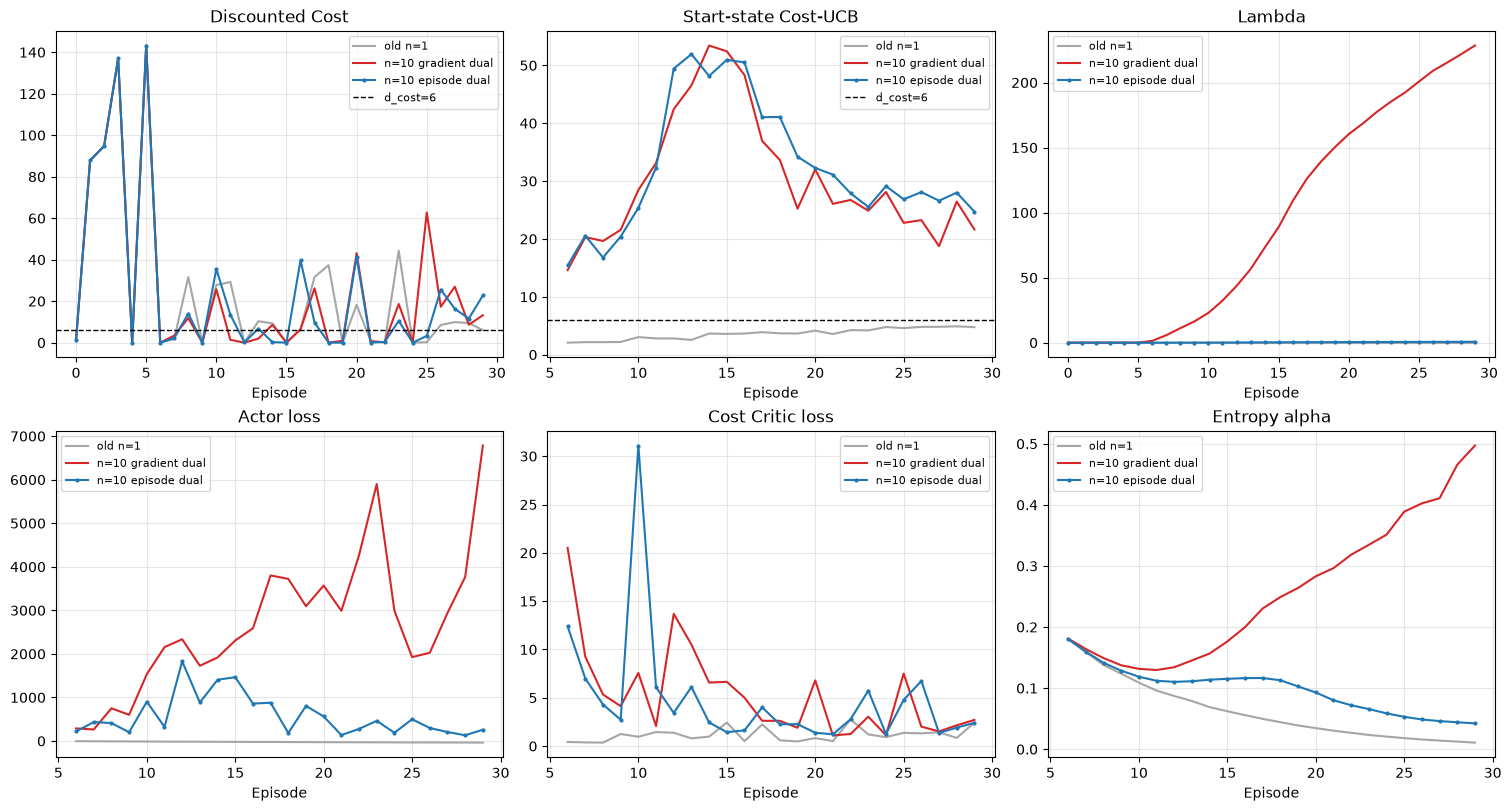

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/online_cal_n10_episode_dual_dcost6_mps/episode_dual_comparison.png


In [6]:
def load_metrics(run):
    path=run/'training'/'metrics.jsonl'
    return [json.loads(x) for x in path.read_text(encoding='utf-8').splitlines() if x.strip()] if path.exists() else []
old_n1=load_metrics(SOURCE_RUN); gradient_n10=load_metrics(GRADIENT_N10_RUN); episode_n10=load_metrics(RUN_DIR)
mc=np.asarray([r['discounted_episode_cost'] for r in calibration['rows']],float); ucb=np.asarray([r['start_state_cost_ucb'] for r in calibration['rows']],float)
summary={'design':{'cost_target_n_step':10,'dual_update_mode':'episode','dual_lr_per_episode':DUAL_LR,'d_cost':D_COST,'episodes':len(episode_n10)},'training':{'environment_steps':episode_n10[-1]['cumulative_environment_steps'],'gradient_updates':episode_n10[-1]['gradient_updates'],'dual_updates':episode_n10[-1].get('dual_update_count',0),'final_lambda':episode_n10[-1]['lambda'],'max_lambda':float(max(r['lambda'] for r in episode_n10)),'mean_discounted_cost':float(np.mean([r['discounted_episode_cost'] for r in episode_n10])),'last10_discounted_cost':float(np.mean([r['discounted_episode_cost'] for r in episode_n10[-10:]])),'mean_actor_loss':float(np.nanmean([r.get('actor_loss',np.nan) for r in episode_n10])),'max_actor_loss':float(np.nanmax([r.get('actor_loss',np.nan) for r in episode_n10])),'success_rate':float(np.mean([r['episode_success'] for r in episode_n10])),'separation_violation_rate':sum(r['separation_violation_pair_ticks'] for r in episode_n10)/max(1,sum(r['active_pair_ticks'] for r in episode_n10))},'calibration':{'mc_mean':float(mc.mean()),'ucb_mean':float(ucb.mean()),'ucb_mae':calibration['overall']['ucb_estimate_mae'],'correlation':calibration['overall']['correlation'],'coverage':calibration['overall']['empirical_ucb_coverage'],'fraction_mc_above_d_cost':float(np.mean(mc>D_COST)),'fraction_ucb_above_d_cost':float(np.mean(ucb>D_COST))}}
(RUN_DIR/'episode_dual_pilot_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8'); display(summary)
fig,axes=plt.subplots(2,3,figsize=(15,8),constrained_layout=True)
series=[('discounted_episode_cost','Discounted Cost'),('dual_constraint_estimate','Start-state Cost-UCB'),('lambda','Lambda'),('actor_loss','Actor loss'),('cost_critic_loss','Cost Critic loss'),('entropy_alpha','Entropy alpha')]
runs=[('old n=1',old_n1,'0.65'),('n=10 gradient dual',gradient_n10,'tab:red'),('n=10 episode dual',episode_n10,'tab:blue')]
for ax,(key,title) in zip(axes.flat,series):
    for label,rows,color in runs:
        if rows: ax.plot([r.get(key,np.nan) for r in rows],label=label,color=color,marker='o' if label.endswith('episode dual') else None,markersize=2)
    if key in {'discounted_episode_cost','dual_constraint_estimate'}: ax.axhline(D_COST,color='black',linestyle='--',linewidth=1,label='d_cost=6')
    ax.set_title(title); ax.set_xlabel('Episode'); ax.grid(alpha=.3); ax.legend(fontsize=8)
figure_path=RUN_DIR/'episode_dual_comparison.png'; fig.savefig(figure_path,dpi=170); plt.show(); print('Saved:',figure_path)